# 10 · Исследование модуля M3 (аукционы ОФЗ Минфина)

**Что это.** Стартовая часть исследования модуля **M3** — аукционы размещения ОФЗ (госдолг). По аналогии с M2: сначала сырые данные и их дыры, затем имеющиеся фичи, затем уже проведённые эксперименты и предварительные выводы. Дальше — по твоей обратной связи — детальная переделка.

**Гипотеза заказчика:** значимость M3 должна быть **≥20%**, а не текущие ~10–11%.

**Экономический смысл M3.** Минфин еженедельно (обычно среда) размещает ОФЗ. Слабый спрос (низкий bid-to-cover, «недоспрос») и премия по доходности = рынок не хочет брать госдолг = индикатор стресса/оттока ликвидности. Сильный спрос («переспрос») = избыток ликвидности.

---
### Что важно держать в голове (предварительно)
1. Текущая важность M3 ≈ **10.7%** (а не 4% — 4% это был M2).
2. M3 **событийный**: аукционы лишь ~**14.6%** дней (среды), остальное в дневном датасете — **zero-fill**.
3. Главная находка прошлых проверок: сигнал `cover_stress` **реальный на днях аукционов** (Spearman −0.31), но **размывается нулями** до −0.05 на всех днях. Проблема M3 — **dilution**, зеркальная к stale-проблеме M2.
4. Данные ОФЗ — только **с 2016**; в 2022 был перерыв размещений (Минфин не выходил на рынок ~7 мес).

## Setup

In [1]:
# --- bootstrap: запускать из корня проекта ---
import sys, os
from pathlib import Path
_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / 'data' / 'processed').is_dir()), _here)
os.chdir(_root); sys.path.insert(0, str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width', 175); pd.set_option('display.max_columns', 60)
import importlib
from lab import utils as u
importlib.reload(u)
print('project root:', _root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


## 1. Сырые данные ОФЗ-аукционов: инвентаризация и дыры

Источник — `data/processed/ofz_auctions.csv` (одна строка = один выпуск на аукционе; в день Минфин размещает несколько выпусков).

In [2]:
raw, dc = u.load_raw_csv('ofz_auctions.csv')
print('строк (выпуск-аукционов):', len(raw), '| колонок:', raw.shape[1])
print('диапазон:', raw[dc].min().date(), '->', raw[dc].max().date())
udays = raw[dc].drop_duplicates().sort_values()
print('уникальных дней аукционов:', len(udays))
print('колонки:', [c for c in raw.columns if c not in ('source_url','source_file')])

строк (выпуск-аукционов): 944 | колонок: 21
диапазон: 2016-01-13 -> 2026-05-06
уникальных дней аукционов: 448
колонки: ['auction_date', 'published_date', 'document_title', 'auction_format', 'issue', 'security_type', 'maturity_date', 'days_to_maturity', 'offered_amount', 'demand_amount', 'placed_amount', 'proceeds_amount', 'cutoff_price', 'weighted_average_price', 'cutoff_yield', 'weighted_average_yield', 'official_coefficient', 'cover_ratio', 'placement_ratio']


### Аукционов по годам (виден провал 2022)

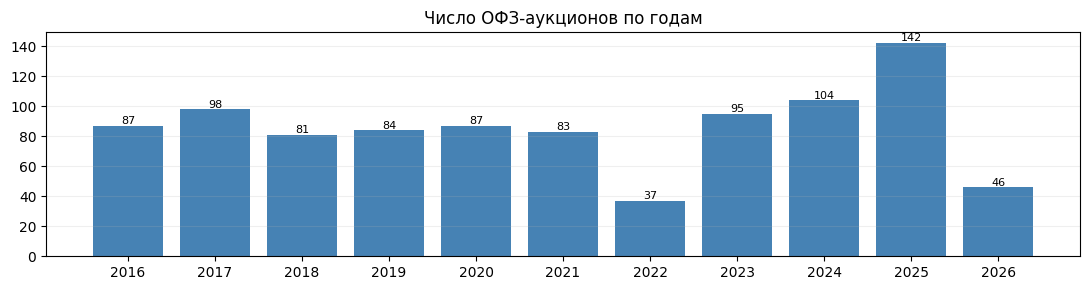

auction_date,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
auctions,87,98,81,84,87,83,37,95,104,142,46


In [3]:
per_year = raw.groupby(raw[dc].dt.year).size()
fig,ax=plt.subplots(figsize=(11,3)); ax.bar(per_year.index.astype(int).astype(str), per_year.values, color='steelblue')
ax.set_title('Число ОФЗ-аукционов по годам'); ax.grid(alpha=.2,axis='y')
for i,v in enumerate(per_year.values): ax.text(i,v+1,str(v),ha='center',fontsize=8)
plt.tight_layout(); plt.show()
display(per_year.rename('auctions').to_frame().T)

### Дыры: интервалы между днями аукционов

интервал между днями аукционов: median=7  p90=7  max=217 дней
крупные паузы (>=21 дня):


,after_date,gap_days
0,2018-04-25,21
1,2018-09-05,28
2,2018-12-26,21
3,2019-12-18,28
4,2020-02-26,42
5,2020-12-23,21
6,2021-12-22,21
7,2022-01-12,21
8,2022-02-09,217
9,2022-09-21,28


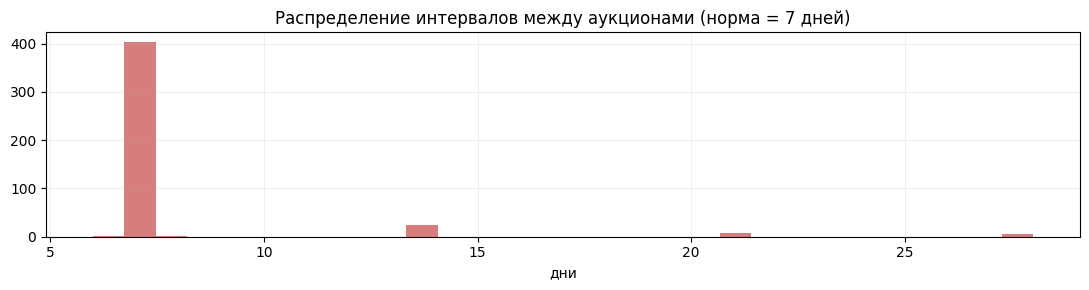

In [4]:
gd = udays.reset_index(drop=True)
gaps = gd.diff().dt.days
g_valid = gaps.dropna()
print('интервал между днями аукционов: median=%.0f  p90=%.0f  max=%.0f дней' % (g_valid.median(),g_valid.quantile(.9),g_valid.max()))
mask = gaps >= 21
big = pd.DataFrame({'after_date': gd.shift(1)[mask].dt.date.values, 'gap_days': gaps[mask].astype(int).values})
print('крупные паузы (>=21 дня):'); display(big)
fig,ax=plt.subplots(figsize=(11,3)); ax.hist(g_valid[g_valid<30],bins=30,color='indianred',alpha=.8)
ax.set_title('Распределение интервалов между аукционами (норма = 7 дней)'); ax.set_xlabel('дни'); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

### Пропуски / нули по сырым колонкам

In [5]:
cols=['offered_amount','demand_amount','placed_amount','cutoff_yield','weighted_average_yield','cover_ratio','placement_ratio']
rows=[]
for c in cols:
    if c in raw.columns:
        s=pd.to_numeric(raw[c],errors='coerce')
        rows.append({'col':c,'null%':round(float(s.isna().mean())*100,1),'zero%':round(float((s==0).mean())*100,1),
                     'min':round(float(s.min()),2),'median':round(float(s.median()),2),'max':round(float(s.max()),1)})
display(pd.DataFrame(rows))
print('Заметки: cutoff/weighted yield null ~11.5%% = несостоявшиеся аукционы (ничего не размещено);')
print('         cover_ratio имеет экстремальные выбросы (крошечный offered) — для графиков клипуем.')

,col,null%,zero%,min,median,max
0,offered_amount,0.0,0.0,3.00,38573.93,1000000.0
1,demand_amount,8.4,0.0,188.79,44516.79,1866476.9
2,placed_amount,0.1,4.7,0.00,19860.52,1000000.0
3,cutoff_yield,11.5,0.3,0.00,8.63,18.4
4,weighted_average_yield,11.5,0.3,0.00,8.61,18.4
5,cover_ratio,8.4,0.0,0.00,0.97,28691.7
6,placement_ratio,0.1,4.7,0.00,0.50,16323.0


Заметки: cutoff/weighted yield null ~11.5%% = несостоявшиеся аукционы (ничего не размещено);
         cover_ratio имеет экстремальные выбросы (крошечный offered) — для графиков клипуем.


### Сырые ряды во времени (event-driven scatter; 2022-пауза заштрихована)

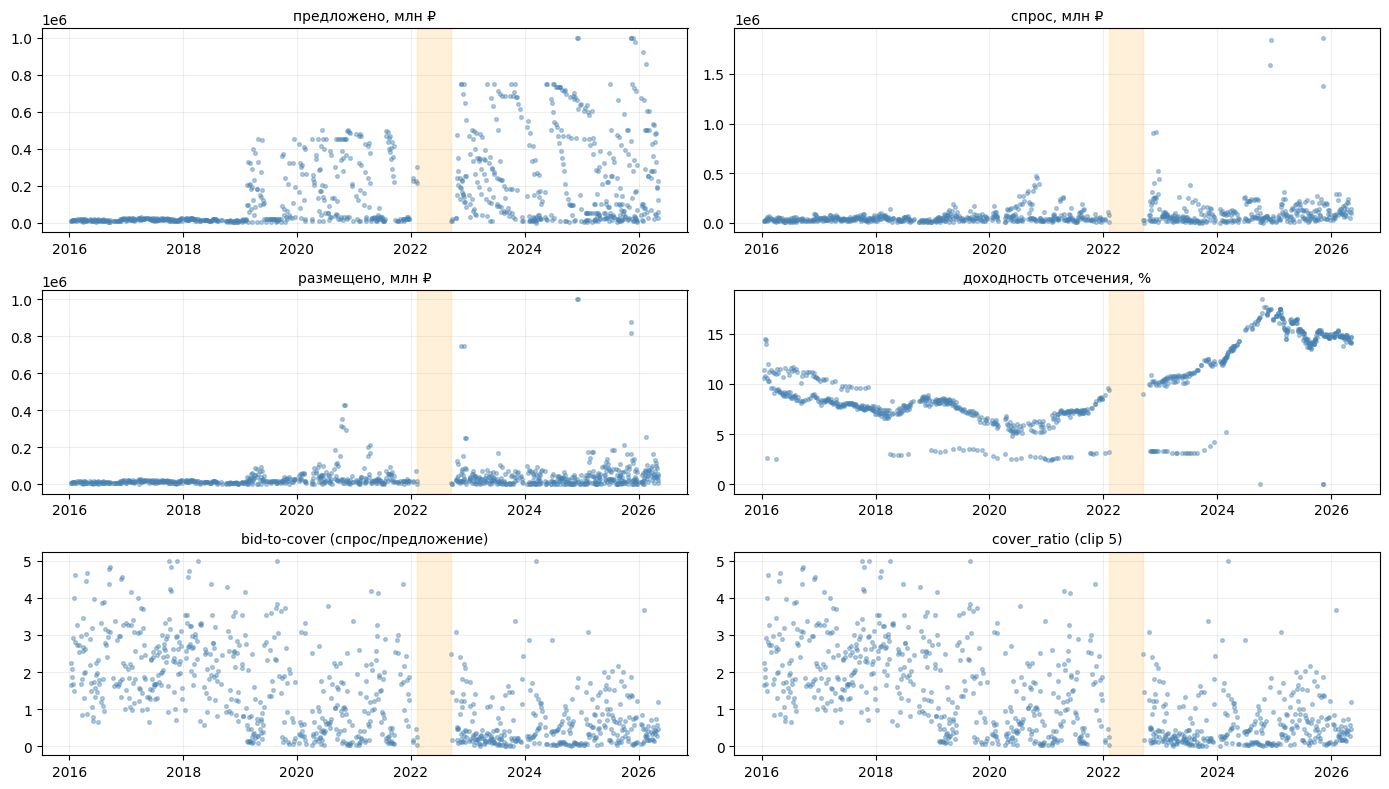

In [6]:
r2=raw.copy(); r2['bid_to_cover']=pd.to_numeric(r2['demand_amount'],errors='coerce')/pd.to_numeric(r2['offered_amount'],errors='coerce')
panels=[('offered_amount','предложено, млн ₽',False),('demand_amount','спрос, млн ₽',False),
        ('placed_amount','размещено, млн ₽',False),('cutoff_yield','доходность отсечения, %',False),
        ('bid_to_cover','bid-to-cover (спрос/предложение)',True),('cover_ratio','cover_ratio (clip 5)',True)]
fig,axes=plt.subplots(3,2,figsize=(14,8))
for ax,(col,title,clip) in zip(axes.ravel(),panels):
    y=pd.to_numeric(r2[col],errors='coerce')
    if clip: y=y.clip(upper=5)
    ax.scatter(r2[dc],y,s=7,alpha=.4,color='steelblue'); ax.set_title(title,fontsize=10); ax.grid(alpha=.2)
    ax.axvspan(pd.Timestamp('2022-02-09'),pd.Timestamp('2022-09-14'),color='orange',alpha=.15)
plt.tight_layout(); plt.show()

### Соотношения спроса / размещения / предложения (исправлено)

Считаем три коэффициента **на день аукциона**, агрегируя выпуски через сумму объёмов (volume-weighted — устойчиво к мелким выпускам). Что каждый означает:

| коэффициент | формула | смысл | о чём говорит рост |
|---|---|---|---|
| **Спрос/Предложение** (`cover_ratio`) | Σспрос / Σпредложено | сколько ₽ заявок на каждый ₽ анонса; **аппетит** к госдолгу | >100% = рынок голодный, облигации нужны; <100% = слабый спрос (стресс/отток) |
| **Размещение/Предложение** (`placement_ratio`) | Σразмещено / Σпредложено | какую долю анонса Минфин реально продал; **успех/исполнение** | ~100% = успешный аукцион; низко = не смог разместить (напряжение) |
| **Спрос/Размещение** (bid-to-cover) | Σспрос / Σразмещено | переподписка на размещённое | высоко = сильно переподписан; failed (размещено=0) = спрос был, но Минфин ничего не дал (острый сигнал) |

Связь: **Спрос/Предложение = (Спрос/Размещение) × (Размещение/Предложение)** — аппетит = переподписка × исполнение.

**Почему прошлый график был странным:** знаменатель `placed` бывает **0** на несостоявшихся аукционах (45 выпусков) → `demand/placed = ∞`, а `clip(500)` сплющивал их в полосу у потолка. Плюс `offered` шумный (от 3 до 1 000 000 млн ₽), поэтому считаем по дневным суммам и клипуем по перцентилям отдельно на панель.

In [7]:
raw, dc = u.load_raw_csv('ofz_auctions.csv')
g = raw.groupby(dc)[['offered_amount','demand_amount','placed_amount']].sum().reset_index()
g.columns = ['date','offered','demand','placed']
g['demand_to_offered'] = g.demand / g.offered * 100               # аппетит (cover_ratio)
g['placed_to_offered'] = g.placed / g.offered * 100               # исполнение (placement_ratio)
g['demand_to_placed']  = np.where(g.demand>0, g.placed/g.demand*100, np.nan)  # переподписка (bid-to-cover)
g['failed'] = (g.placed==0).astype(int)                            # несостоявшийся аукцион
pause = (pd.Timestamp('2022-02-09'), pd.Timestamp('2022-09-21'))
METRICS = [('demand_to_offered','Спрос / Предложение (аппетит)','steelblue',450),
           ('placed_to_offered','Размещение / Предложение (исполнение)','forestgreen',120),
           ('demand_to_placed','Размещено / Спрос (%)','indianred',100)]
print('дней аукционов:', len(g), '| несостоявшихся (placed=0):', int(g.failed.sum()))
for col,_,_,cap in METRICS:
    s=g[col]; print(f'  {col:18s} median={s.median():.0f}%  p90={s.quantile(.9):.0f}%  clip={cap}%  обрезано={int((s>cap).sum())}')

дней аукционов: 448 | несостоявшихся (placed=0): 9
  demand_to_offered  median=76%  p90=285%  clip=450%  обрезано=3
  placed_to_offered  median=43%  p90=100%  clip=120%  обрезано=1
  demand_to_placed   median=50%  p90=73%  clip=100%  обрезано=0


#### График с точками (каждая точка = день аукциона)

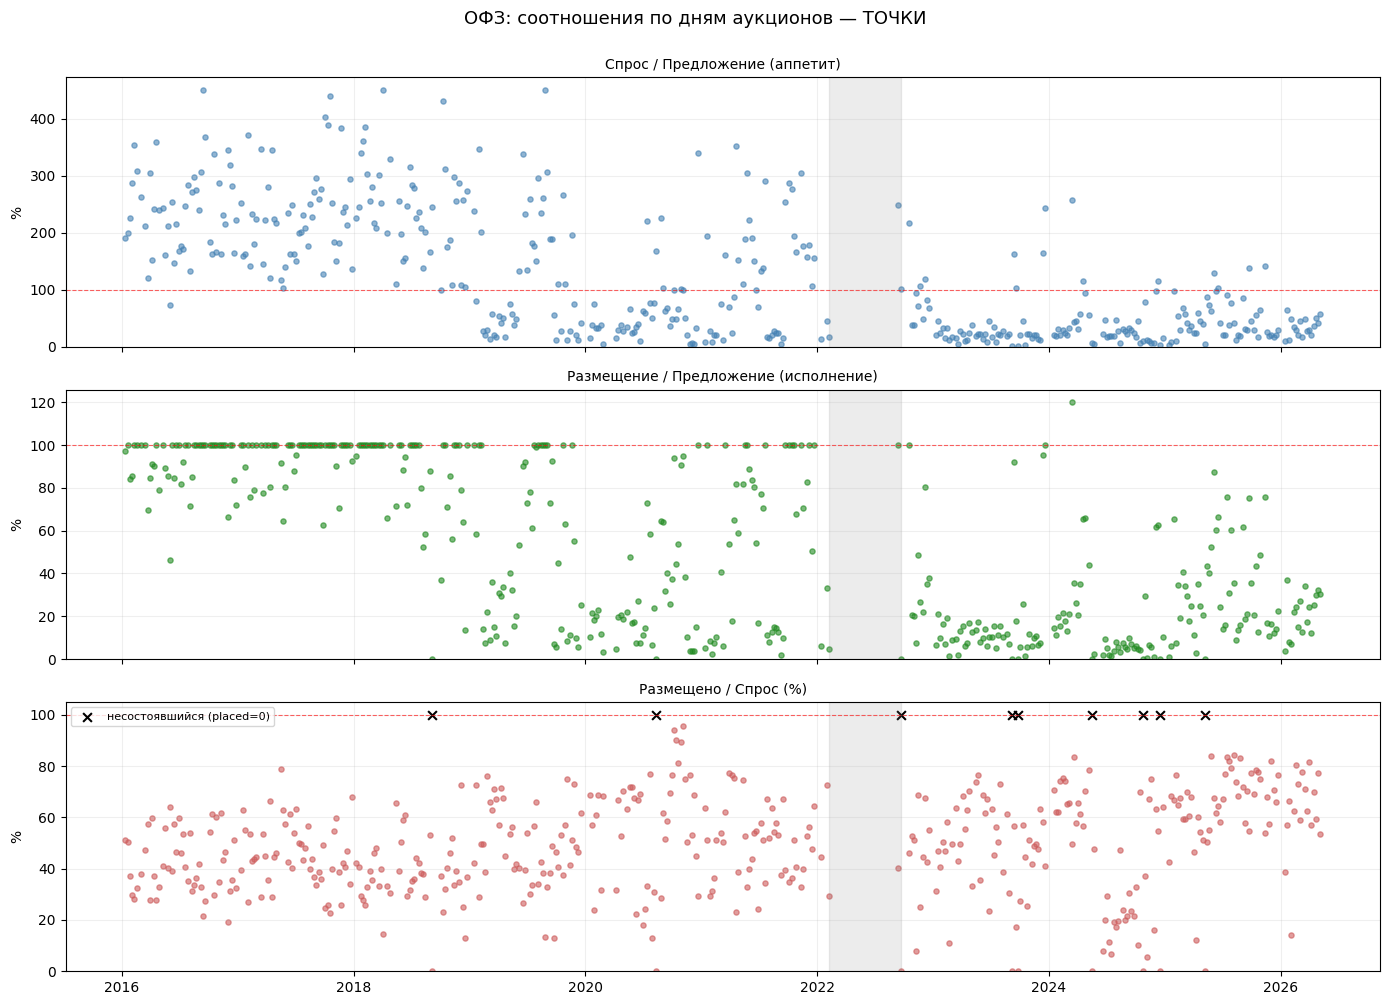

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('ОФЗ: соотношения по дням аукционов — ТОЧКИ', fontsize=13, y=1.0)
for ax,(col,title,color,cap) in zip(axes, METRICS):
    s = g[col].clip(upper=cap)
    ax.scatter(g['date'], s, s=14, color=color, alpha=0.6)
    # несостоявшиеся аукционы — красные крестики у потолка панели
    if col=='demand_to_placed':
        fl=g[g.failed==1]; ax.scatter(fl['date'], np.full(len(fl),cap), s=40, marker='x', color='black', label='несостоявшийся (placed=0)'); ax.legend(fontsize=8,loc='upper left')
    ax.axhline(100, color='red', ls='--', lw=0.8, alpha=0.6)
    ax.axvspan(*pause, color='gray', alpha=0.15)
    ax.set_title(title, fontsize=10); ax.set_ylabel('%'); ax.set_ylim(0, cap*1.05); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

#### График с линиями (скользящая медиана по 8 аукционам — тренд)

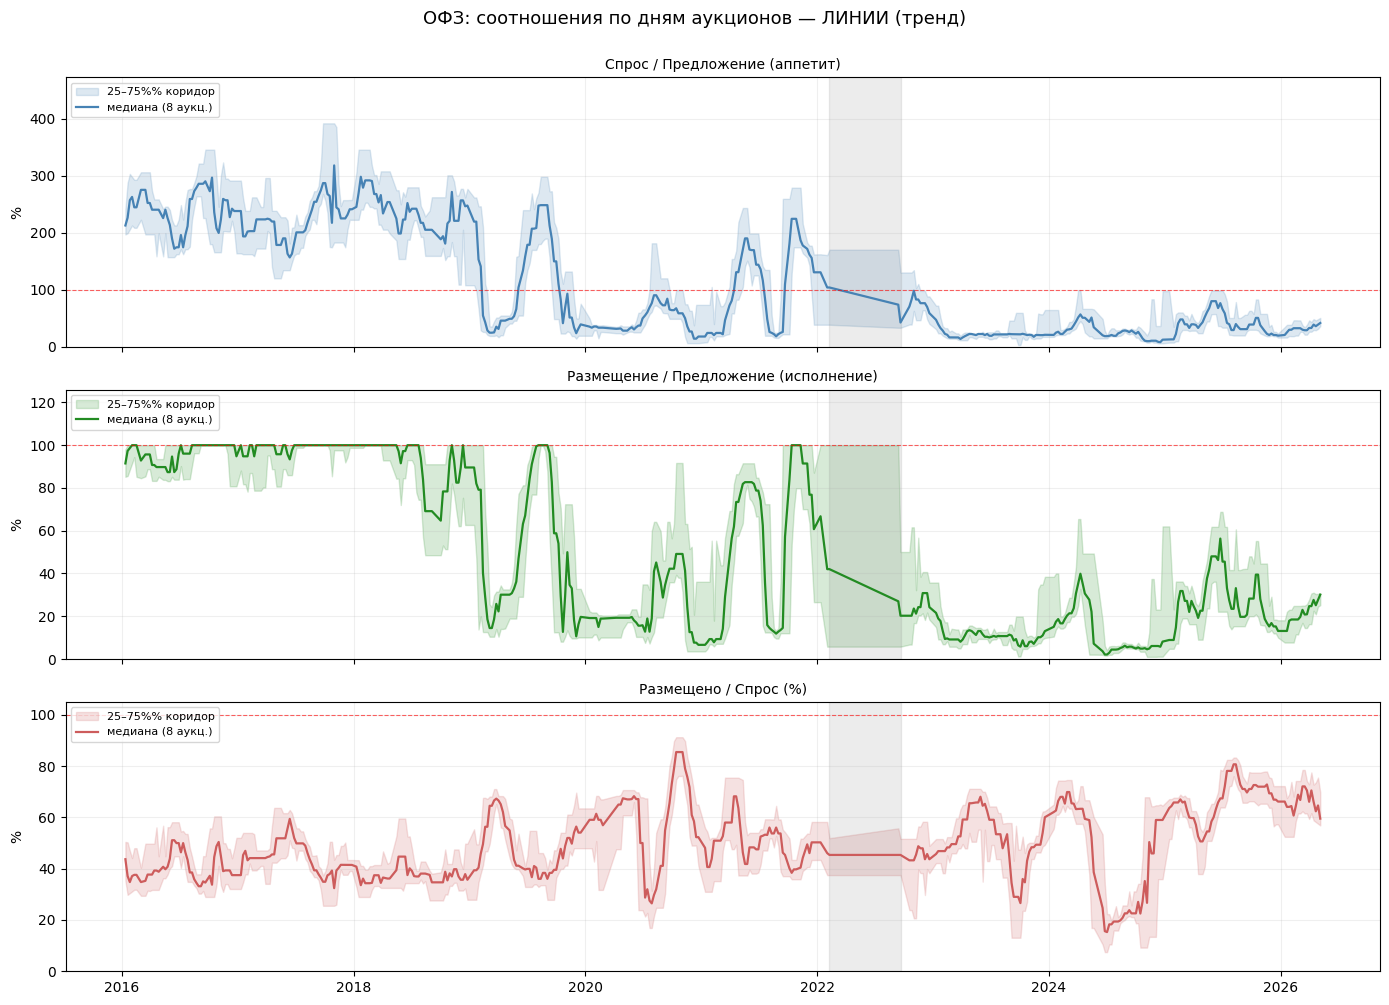

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('ОФЗ: соотношения по дням аукционов — ЛИНИИ (тренд)', fontsize=13, y=1.0)
for ax,(col,title,color,cap) in zip(axes, METRICS):
    s = g[col].clip(upper=cap)
    roll_med = s.rolling(8, min_periods=3, center=True).median()
    roll_q1  = s.rolling(8, min_periods=3, center=True).quantile(0.25)
    roll_q3  = s.rolling(8, min_periods=3, center=True).quantile(0.75)
    ax.fill_between(g['date'], roll_q1, roll_q3, color=color, alpha=0.18, label='25–75%% коридор')
    ax.plot(g['date'], roll_med, color=color, lw=1.6, label='медиана (8 аукц.)')
    ax.axhline(100, color='red', ls='--', lw=0.8, alpha=0.6)
    ax.axvspan(*pause, color='gray', alpha=0.15)
    ax.set_title(title, fontsize=10); ax.set_ylabel('%'); ax.set_ylim(0, cap*1.05); ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

In [10]:
summary = g[['demand_to_offered','placed_to_offered','demand_to_placed']].describe().round(1)
summary.columns = ['Спрос/Предложение %','Размещение/Предложение %','Размещение/Спрос %']
display(summary)
print('Чтение: высокий Спрос/Предложение + высокое Размещение = рынок голодный (избыток ликвидности);')
print('        низкие оба (и провалы/failed) = слабый спрос на госдолг = стресс/отток ликвидности.')

,Спрос/Предложение %,Размещение/Предложение %,Размещение/Спрос %
count,448.0,448.0,448.0
mean,123.5,51.3,48.7
std,115.9,38.9,19.1
min,1.1,0.0,0.0
25%,25.0,12.8,35.5
50%,75.9,43.5,49.7
75%,211.8,100.0,63.3
max,758.8,127.5,95.7


Чтение: высокий Спрос/Предложение + высокое Размещение = рынок голодный (избыток ликвидности);
        низкие оба (и провалы/failed) = слабый спрос на госдолг = стресс/отток ликвидности.


## 2. Имеющиеся фичи M3

`data/processed/m3_features.csv` — одна строка на **день аукциона** (448 строк). В дневной `final_ml_dataset` эти величины мёрджатся по дате, а **не-аукционные дни зануляются** (zero-fill).

In [11]:
mf,_=u.load_raw_csv('m3_features.csv')
feat_cols=[c for c in mf.columns if c!='date']
rows=[]
for c in feat_cols:
    s=pd.to_numeric(mf[c],errors='coerce')
    rows.append({'feature':c,'null%':round(float(s.isna().mean())*100,1),'zero%':round(float((s==0).mean())*100,1),
                 'n_unique':int(s.nunique()),'std':round(float(s.std()),3)})
display(pd.DataFrame(rows))

,feature,null%,zero%,n_unique,std
0,demand_amount,0.0,0.0,448,229828.434
1,offered_amount,0.0,0.0,311,381675.219
2,placed_amount,0.0,2.0,409,136367.089
3,weighted_yield,5.6,0.0,420,3.561
4,cover_ratio,0.0,0.0,448,1.159
5,yield_spread,5.8,0.0,420,1.834
6,Flag_Nedospros,0.0,41.7,2,0.494
7,Flag_Perespros,0.0,73.4,2,0.442
8,MAD_score_cover,0.0,0.9,443,2.167
9,MAD_score_yield_spread,5.8,0.7,417,3.723


### Что означает каждая фича
| фича m3_features | смысл |
|---|---|
| `demand_amount/offered_amount/placed_amount` | объёмы спроса / предложения / размещения (млн ₽) |
| `cover_ratio` | bid-to-cover = спрос/размещение (спрос на госдолг) |
| `weighted_yield`, `yield_spread` | средневзвешенная доходность и её спред (премия) |
| `Flag_Nedospros` | флаг **недоспроса** (спрос < предложения) |
| `Flag_Perespros` | флаг **переспроса** (ажиотаж) |
| `MAD_score_cover` | MAD-score cover_ratio (аномальность спроса) |
| `MAD_score_yield_spread` | MAD-score премии доходности |

**Маппинг в whitelist (что видит PCA):** `m3_cover_stress_score = −MAD_score_cover` (низкий спрос = стресс, знак инвертирован), `m3_yield_stress_score = MAD_score_yield_spread`, плюс `m3_Flag_Nedospros`, `m3_Flag_Perespros`, `m3_auction_flag`.

### Распределения фич m3_features (по дням аукционов)

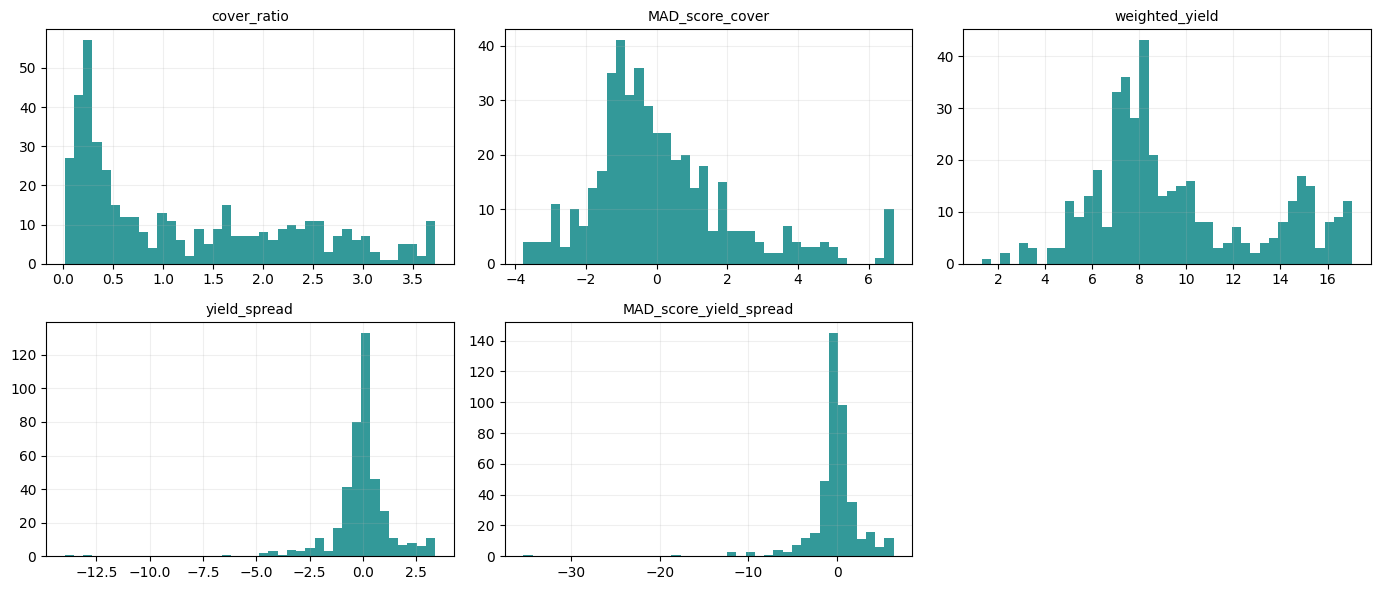

In [12]:
show=['cover_ratio','MAD_score_cover','weighted_yield','yield_spread','MAD_score_yield_spread']
fig,axes=plt.subplots(2,3,figsize=(14,6))
for ax,c in zip(axes.ravel(),show):
    ax.hist(pd.to_numeric(mf[c],errors='coerce').dropna().clip(upper=pd.to_numeric(mf[c],errors='coerce').quantile(.98)),bins=40,color='teal',alpha=.8)
    ax.set_title(c,fontsize=10); ax.grid(alpha=.2)
axes.ravel()[-1].axis('off'); plt.tight_layout(); plt.show()

### Zero-fill в дневном датасете — корень проблемы dilution

In [13]:
d=u.load_final_dataset(); base_wl=u.available_whitelist(d)
m3cols=[c for c in d.columns if c.startswith('m3_')]
print('M3 колонок в final_ml_dataset:', len(m3cols))
print('m3_auction_flag==1 (доля дней с аукционом):', round(float((d['m3_auction_flag']==1).mean()),3))
zr=pd.DataFrame([{'feature':c,'zero%':round(float((pd.to_numeric(d[c],errors='coerce')==0).mean())*100,1),
                 'in_whitelist':c in base_wl} for c in m3cols])
display(zr.sort_values('zero%',ascending=False))

M3 колонок в final_ml_dataset: 16
m3_auction_flag==1 (доля дней с аукционом): 0.146


,feature,zero%,in_whitelist
7,m3_Flag_Perespros,96.1,True
6,m3_Flag_Nedospros,91.5,True
12,m3_yield_spread_available,86.3,False
2,m3_placed_amount,85.7,False
8,m3_MAD_score_cover,85.6,False
13,m3_cover_stress_score,85.6,True
9,m3_MAD_score_yield_spread,85.5,False
14,m3_yield_stress_score,85.5,True
0,m3_demand_amount,85.4,False
1,m3_offered_amount,85.4,False


## 3. Уже проведённые эксперименты и предварительные выводы

Здесь собрано то, что мы уже выяснили по M3 (в т.ч. в аудите ноутбука 09). Это отправная точка для детальной переделки.

In [14]:
art=u.fit_lsi_like_model(d,base_wl)
mc=u.module_contributions(art['scaled_matrix'],art['pca'],art['features']).mean().round(2)
print('Текущие доли модулей в индексе:'); print({k:float(v) for k,v in mc.items()})
print('-> M3 сейчас = %.2f%% (цель заказчика >=20%%)' % float(mc['M3']))

Текущие доли модулей в индексе:
{'M1': 37.05, 'M2': 4.73, 'M3': 10.72, 'M4': 29.25, 'M5': 18.25}
-> M3 сейчас = 10.72% (цель заказчика >=20%)


### Эксперимент 1 — dilution: сигнал есть на аукционах, но размыт нулями

In [15]:
lsi=art['lsi']; af=d['m3_auction_flag'].fillna(0).values
age=np.empty(len(d)); last=-10**9
for i,v in enumerate(af):
    if v==1: last=i
    age[i]=i-last if last>-10**8 else 9999
age=pd.Series(age)
print('доля дней с аукционом: %.3f | median age с аукциона: %.0f дн (≈недельный цикл)'%((af==1).mean(),age.median()))
rows=[]
for c in ['m3_cover_stress_score','m3_yield_stress_score','m3_Flag_Nedospros','m3_Flag_Perespros']:
    s=pd.to_numeric(d[c],errors='coerce'); m=((age<=3)&(s!=0)).values
    sa=u.spearman(s.values,lsi); sf=u.spearman(s.values[m],lsi[m]) if m.sum()>30 else float('nan')
    rows.append({'feature':c,'Sp_all':round(sa,3),'Sp_fresh(age<=3)':round(sf,3),
                 'усиление':round(abs(sf)/abs(sa),1) if abs(sa)>1e-6 and not np.isnan(sf) else None,
                 'zero%':round(float((s==0).mean())*100,1)})
display(pd.DataFrame(rows))

доля дней с аукционом: 0.146 | median age с аукциона: 3 дн (≈недельный цикл)


/Users/nikitabaslykov/Documents/Работа/Казначейство/MathMode_LiquidityCatchers_RuLiquiditySentinel/lab/utils.py:217: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(a[m], b[m]).correlation)


,feature,Sp_all,Sp_fresh(age<=3),усиление,zero%
0,m3_cover_stress_score,-0.051,-0.306,6.0,85.6
1,m3_yield_stress_score,-0.015,-0.016,1.0,85.5
2,m3_Flag_Nedospros,0.103,NaN,NaN,91.5
3,m3_Flag_Perespros,-0.004,NaN,NaN,96.1


**Вывод эксперимента 1.** `m3_cover_stress_score` несёт **реальный сигнал на днях аукционов** (Spearman −0.31), но на всех днях он падает до −0.05 — в **6 раз слабее** — из-за zero-fill на 85% не-аукционных дней. Это **недоиспользование**, а не stale-артефакт. `m3_yield_stress_score` слаб даже на свежих (−0.02). `m3_Flag_Perespros` почти мёртв (zero 92%, Sp ≈ 0).

### Эксперимент 2 — cover_stress на днях аукционов vs LSI (визуально)

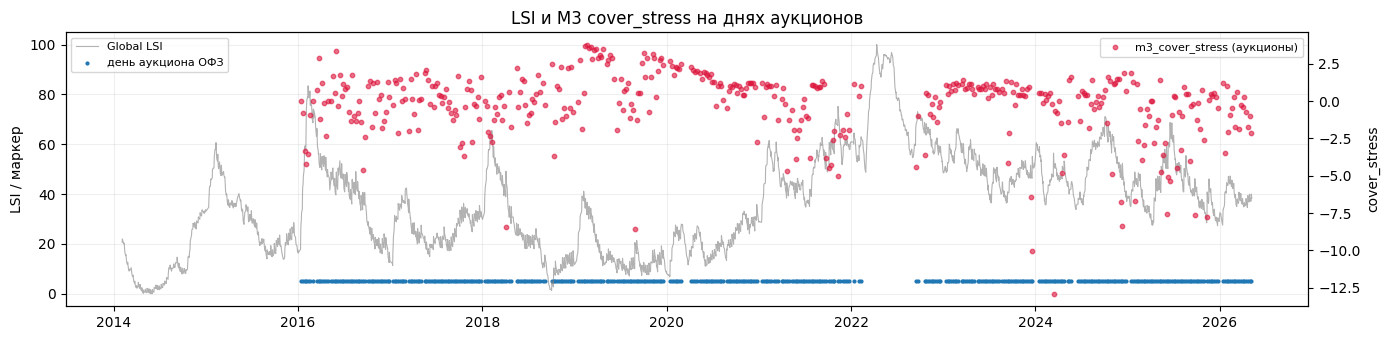

In [16]:
dts=pd.to_datetime(d['date'])
auc=(age<=0).values  # ровно дни аукционов
fig,ax=plt.subplots(figsize=(14,3.5))
ax2=ax.twinx()
ax.plot(dts,lsi,color='gray',lw=.8,alpha=.6,label='Global LSI')
ax.scatter(dts[auc],np.full(auc.sum(),5),s=4,color='tab:blue',label='день аукциона ОФЗ')
cs=pd.to_numeric(d['m3_cover_stress_score'],errors='coerce').values
ax2.scatter(dts[auc],cs[auc],s=10,color='crimson',alpha=.6,label='m3_cover_stress (аукционы)')
ax.set_ylabel('LSI / маркер'); ax2.set_ylabel('cover_stress'); ax.set_title('LSI и M3 cover_stress на днях аукционов')
ax.legend(loc='upper left',fontsize=8); ax2.legend(loc='upper right',fontsize=8); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## Предварительные выводы и открытые вопросы (жду обратную связь)

**Что уже понятно:**
1. M3 сейчас ≈ **10.7%** — ниже ожидаемых 20%, но не из-за отсутствия сигнала, а из-за того, что сигнал **разбавлен zero-fill** (аукционы лишь 14.6% дней).
2. Главный носитель сигнала — **спрос на ОФЗ** (`cover_stress`, −0.31 на аукционах). Доходностный спред (`yield_stress`) пока слаб. Флаги недо/переспроса — недо чуть живой (0.10), пере почти мёртв.
3. Проблема **зеркальна к M2**: там был stale-ffill (протухшие значения), здесь — **dilution** (сигнал гасится нулями между аукционами).

**Гипотезы для детальной проверки (следующий этап, как в M2):**
- **H-M3-1 — event-aware представление вместо zero-fill.** Заменить нули на last-known + `age`/`available` (как сделали для M2). Ожидание: важность M3 и корреляция вырастут без артефакта.
- **H-M3-2 — раздельная статистика по типам аукциона / срочности ОФЗ** (`days_to_maturity`, `security_type`): возможно, стресс в длинных ОФЗ ≠ в коротких (аналог tier-split M2).
- **H-M3-3 — leading-сигнал недоспроса.** `Flag_Nedospros` / премия доходности как опережающий индикатор (Spearman с LSI T+1/T+7).
- **H-M3-4 — yield_spread к ОФЗ-кривой/ключевой ставке** как «цена» размещения (по аналогии с cutoff_spread в M2, который оказался лучшим сигналом).
- **H-M3-5 — фикс выбросов cover_ratio** (max 28691) — клиппинг/винзоризация перед MAD.

**Открытые вопросы к тебе:**
- Какой горизонт важнее для M3 — concurrent (текущий стресс размещения) или leading (предсказание)?
- Учитывать ли провал 2022 особо (7 мес без аукционов = структурный сигнал сам по себе)?
- Ок ли переходить на event-aware представление (H-M3-1) как основной фикс, по аналогии с M2?

После твоей обратной связи — разворачиваю детальное исследование с ablation и демонстрацией сигнала, как в ноутбуке 08.

---
## 4. Полная проверка гипотез A–F

Тестируем все предложенные гипотезы: **A** placement (placed/offered), **B** доходность (уровень cutoff и спред cutoff−key), **C** constant-maturity доходность, **D** event-aware представление вместо zero-fill, **E** флаг несостоявшегося аукциона, **F** rejection.

> Ключевая ставка берётся из `data/processed/keyrate.csv` (с 2013, дневная) — отдельно записывать не нужно.

In [17]:
raw, dc = u.load_raw_csv('ofz_auctions.csv')
for c in ['offered_amount','demand_amount','placed_amount','cutoff_yield','days_to_maturity']:
    raw[c]=pd.to_numeric(raw[c],errors='coerce')
def _agg(x):
    off,dem,pla=x.offered_amount.sum(),x.demand_amount.sum(),x.placed_amount.sum()
    wy=(x.cutoff_yield*x.placed_amount).sum()/pla if pla>0 else np.nan
    wm=(x.days_to_maturity*x.placed_amount).sum()/pla if pla>0 else np.nan
    return pd.Series({'offered':off,'demand':dem,'placed':pla,'cutoff_y':wy,'w_mat':wm})
g=raw.groupby(dc).apply(_agg).reset_index().rename(columns={dc:'date'}); g['date']=pd.to_datetime(g['date']); g=g.sort_values('date').reset_index(drop=True)
g['cover']=g.demand/g.offered; g['placement']=g.placed/g.offered
g['bid_to_cover']=np.where(g.placed>0,g.demand/g.placed,np.nan)
g['rejection']=np.where(g.demand>0,1-g.placed/g.demand,np.nan); g['failed']=(g.placed==0).astype(int)
k=pd.read_csv('data/processed/keyrate.csv'); k['date']=pd.to_datetime(k['date'],dayfirst=True,format='mixed'); k=k.sort_values('date')
g=pd.merge_asof(g,k,on='date',direction='backward')
g['yield_level']=g.cutoff_y; g['yield_to_key']=g.cutoff_y-g.key_rate
mm=g.dropna(subset=['cutoff_y','w_mat']); b=np.polyfit(mm.w_mat,mm.cutoff_y,1)
g['cm_yield_resid']=g.cutoff_y-(b[0]*g.w_mat+b[1])
d=u.load_final_dataset(); base_wl=u.available_whitelist(d); cal=d[['date']].copy()
art_A=u.fit_lsi_like_model(d,base_wl); lsi=art_A['lsi']; lsiS=pd.Series(lsi,index=pd.to_datetime(d['date']))
g['lsi']=g['date'].map(lsiS); gv=g.dropna(subset=['lsi'])
def mad_series(col):
    s=g.dropna(subset=[col]).copy().sort_values('date'); vals=s[col].values; dts=s['date'].values; out=[]; W=np.timedelta64(365*3,'D')
    for i in range(len(s)):
        w=vals[(dts>dts[i]-W)&(dts<=dts[i])]; med=np.median(w); mad=max(np.median(np.abs(w-med)),0.05); out.append((vals[i]-med)/mad)
    s['mad']=out; return s[['date','mad']]
print('g построен:', g.shape, '| дней с LSI:', len(gv))

/tmp/claude-501/ipykernel_39458/272074631.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g=raw.groupby(dc).apply(_agg).reset_index().rename(columns={dc:'date'}); g['date']=pd.to_datetime(g['date']); g=g.sort_values('date').reset_index(drop=True)


g построен: (448, 16) | дней с LSI: 448


### A–F: коэффициенты (Spearman с LSI на днях аукционов)

In [18]:
tests=[('cover=demand/offered (текущ.)','cover'),('H-A placement=placed/offered','placement'),
       ('bid_to_cover=demand/placed','bid_to_cover'),('H-F rejection=1-placed/demand','rejection'),
       ('H-B1 yield_level=cutoff','yield_level'),('H-B2 yield_to_key=cutoff-key','yield_to_key'),
       ('H-C cm_yield_resid','cm_yield_resid'),('H-E failed_flag','failed')]
pd.DataFrame([{'гипотеза':nm,'Spearman_LSI':round(u.spearman(gv[c],gv.lsi),3),'std':round(float(gv[c].std()),3)} for nm,c in tests])

,гипотеза,Spearman_LSI,std
0,cover=demand/offered (текущ.),-0.234,1.159
1,H-A placement=placed/offered,-0.227,0.389
2,bid_to_cover=demand/placed,-0.011,1.722
3,H-F rejection=1-placed/demand,-0.003,0.191
4,H-B1 yield_level=cutoff,0.201,4.248
5,H-B2 yield_to_key=cutoff-key,-0.203,3.742
6,H-C cm_yield_resid,0.153,4.200
7,H-E failed_flag,0.029,0.140


### Leading T+0 vs T+7 (event-aware ffill cap 14д)

In [19]:
def daily(col,cap=14):
    s=g.dropna(subset=[col]).sort_values('date')[['date',col]]
    dd=pd.merge_asof(cal.sort_values('date'),s,on='date',direction='backward',tolerance=pd.Timedelta(days=cap))
    return pd.Series(dd[col].values,index=pd.to_datetime(cal['date']))
rows=[]
for nm in ['cover','placement','yield_to_key','yield_level']:
    ser=daily(nm); rows.append({'feature':nm,'T+0':round(u.spearman(ser.reindex(lsiS.index).values,lsiS.values),3),
                                'T+7':round(u.spearman(ser.reindex(lsiS.index).values,lsiS.shift(-7).values),3)})
pd.DataFrame(rows)

,feature,T+0,T+7
0,cover,-0.233,-0.226
1,placement,-0.216,-0.211
2,yield_to_key,-0.185,-0.179
3,yield_level,0.190,0.178


### H-D — главный фикс: event-aware vs zero-fill
Берём MAD-score каждого сигнала на днях аукционов и сравниваем два дневных представления: **zero-fill** (как сейчас, нули между аукционами) и **event-aware** (last-known ffill).

In [20]:
rows=[]
for nm,col,sign in [('cover_stress','cover',-1),('placement_stress','placement',-1),('yield_to_key_stress','yield_to_key',1)]:
    ms=mad_series(col); ms['mad']=ms['mad']*sign
    zf=cal.merge(ms,on='date',how='left'); zf_s=zf['mad'].fillna(0).values
    ea=pd.merge_asof(cal.sort_values('date'),ms.sort_values('date'),on='date',direction='backward'); ea_s=ea['mad'].values
    rows.append({'signal':nm,'zero-fill (сейчас)':round(u.spearman(zf_s,lsi),3),'event-aware':round(u.spearman(ea_s,lsi),3)})
display(pd.DataFrame(rows))
print('Вывод: zero-fill режет сигнал в 4–6 раз. Event-aware его восстанавливает.')

,signal,zero-fill (сейчас),event-aware
0,cover_stress,-0.051,-0.230
1,placement_stress,-0.051,-0.306
2,yield_to_key_stress,-0.059,-0.209


Вывод: zero-fill режет сигнал в 4–6 раз. Event-aware его восстанавливает.


### Ablation — важность модуля M3 при разных наборах

In [21]:
feats={}
for nm,col,sign in [('m3x_cover','cover',-1),('m3x_placement','placement',-1),('m3x_yield_to_key','yield_to_key',1)]:
    ms=mad_series(col); ms['mad']=ms['mad']*sign
    ea=pd.merge_asof(cal.sort_values('date'),ms.sort_values('date'),on='date',direction='backward'); feats[nm]=ea['mad'].values
af=d['m3_auction_flag'].fillna(0).values; age=np.empty(len(d)); last=-10**9
for i,v in enumerate(af):
    if v==1: last=i
    age[i]=i-last if last>-10**8 else 9999
gx=d.copy()
for nm,v in feats.items(): gx[nm]=v
gx['m3x_age']=np.minimum(age,90); gx['m3x_available']=(age<=10).astype(int)
fdays=set(g[g.failed==1]['date']); gx['m3x_failed']=gx['date'].isin(fdays).astype(int); gx=gx.fillna(0)
def m3_share(cols):
    a=u.fit_lsi_like_model(gx,cols); sw=np.abs(a['pca'].components_).T@a['pca'].explained_variance_ratio_
    con=np.abs(a['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    idx=[i for i,f in enumerate(a['features']) if f.startswith('m3')]
    return round(float(con[:,idx].sum(1).mean()),2), round(u.spearman(a['lsi'],lsi),4)
non_m3=[x for x in base_wl if not x.startswith('m3')]; KEEP=['m3_auction_flag','m3_Flag_Nedospros']
sets=[('A current M3',base_wl),
      ('B +event-aware cover',non_m3+KEEP+['m3x_cover','m3x_age','m3x_available']),
      ('C +placement',non_m3+KEEP+['m3x_cover','m3x_placement','m3x_age','m3x_available']),
      ('D +yield_to_key (fix)',non_m3+KEEP+['m3x_cover','m3x_placement','m3x_yield_to_key','m3x_age','m3x_available']),
      ('E full +failed',non_m3+KEEP+['m3x_cover','m3x_placement','m3x_yield_to_key','m3x_age','m3x_available','m3x_failed'])]
rows=[]
for nm,cols in sets:
    sh,sp=m3_share(cols); rows.append({'set':nm,'M3_share%':sh,'Sp_vs_A':sp})
display(pd.DataFrame(rows))

,set,M3_share%,Sp_vs_A
0,A current M3,10.72,1.0000
1,B +event-aware cover,21.15,0.8632
2,C +placement,24.41,0.6844
3,D +yield_to_key (fix),27.37,0.7168
4,E full +failed,27.61,0.7581


### Демонстрация на истории — зажигается ли улучшенный M3 в стрессах (2022)?
Сравниваем вклад модуля M3 во времени: текущий набор vs полный event-aware (set E). Оранжевым — стресс-эпизоды, серым — пауза размещений ОФЗ 2022.

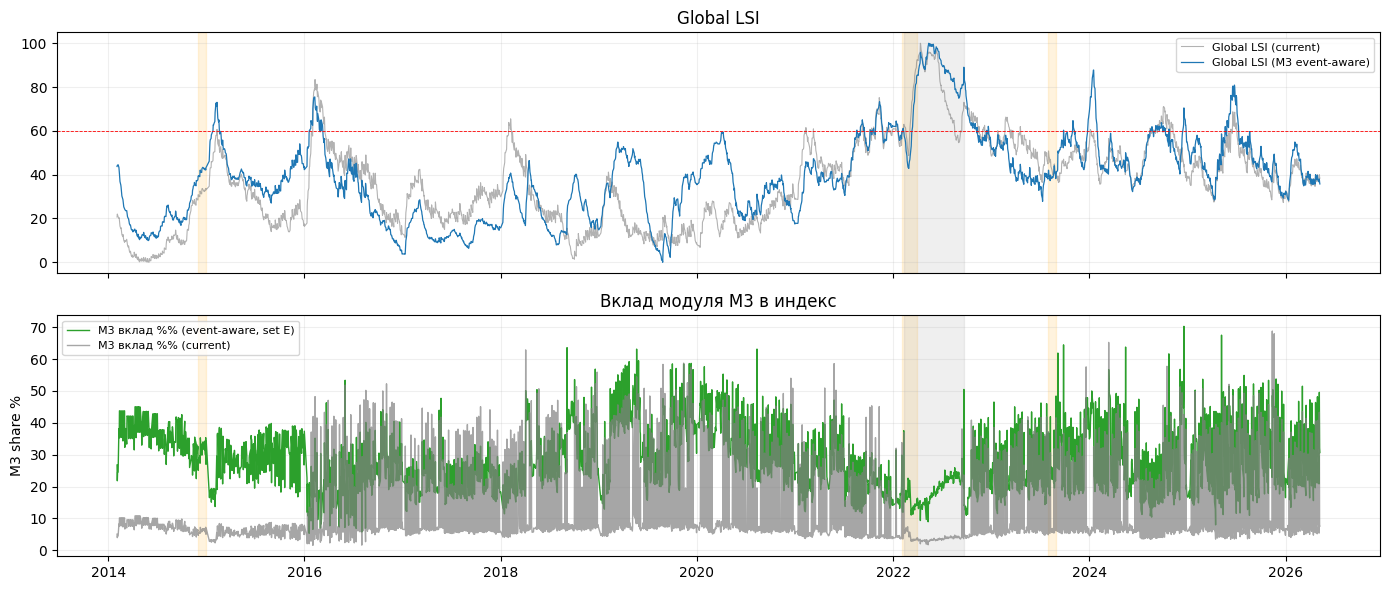

M3 вклад (event-aware): в стресс-эпизодах=23.0%  вне=27.8% | current: стресс=7.4% вне=10.8%


In [22]:
def m3_contrib_ts(cols):
    a=u.fit_lsi_like_model(gx,cols); sw=np.abs(a['pca'].components_).T@a['pca'].explained_variance_ratio_
    con=np.abs(a['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    idx=[i for i,f in enumerate(a['features']) if f.startswith('m3')]; return con[:,idx].sum(1), a['lsi']
m3_cur,_=m3_contrib_ts(base_wl)
m3_full,lsi_full=m3_contrib_ts(sets[-1][1])
dts=pd.to_datetime(d['date'])
fig,ax=plt.subplots(2,1,figsize=(14,6),sharex=True)
ax[0].plot(dts,lsi,color='gray',lw=.8,alpha=.6,label='Global LSI (current)')
ax[0].plot(dts,lsi_full,color='tab:blue',lw=.9,label='Global LSI (M3 event-aware)')
ax[0].axhline(60,color='r',ls='--',lw=.6); ax[0].set_title('Global LSI'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.2)
ax[1].plot(dts,m3_full,color='tab:green',lw=1,label='M3 вклад %% (event-aware, set E)')
ax[1].plot(dts,m3_cur,color='gray',lw=1,alpha=.7,label='M3 вклад %% (current)')
ax[1].set_title('Вклад модуля M3 в индекс'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.2); ax[1].set_ylabel('M3 share %')
for a in ax:
    for nm,(s,e) in u.STRESS_EPISODES.items(): a.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
    a.axvspan(pd.Timestamp('2022-02-09'),pd.Timestamp('2022-09-21'),color='gray',alpha=.12)
plt.tight_layout(); plt.show()
ep=pd.Series(False,index=range(len(d)))
for nm,(s,e) in u.STRESS_EPISODES.items(): ep |= ((dts>=s)&(dts<=e)).values
print('M3 вклад (event-aware): в стресс-эпизодах=%.1f%%  вне=%.1f%% | current: стресс=%.1f%% вне=%.1f%%'%(
      m3_full[ep.values].mean(),m3_full[~ep.values].mean(),m3_cur[ep.values].mean(),m3_cur[~ep.values].mean()))

### Verdict по гипотезам A–F
| H | фича | Spearman | вердикт |
|---|---|---|---|
| **D** | event-aware вместо zero-fill | cover −0.05→−0.23, placement −0.05→−0.31 | **ГЛАВНЫЙ фикс**: M3 10.7%→21% только за счёт него |
| **A** | placement = placed/offered | −0.227 | **принять**: сильный ортогональный сигнал, ранее выкинут |
| **B2** | yield_to_key = cutoff−key | −0.203 | **принять**: чинит сломанный yield_spread (был ≈0) |
| B1 | yield_level = cutoff | +0.201 | альтернатива B2 (level тянет режим ставок); берём B2 |
| **E** | failed-флаг (placed=0) | +0.029 univ. | принять как маркер экстремума (мало точек) |
| C | constant-maturity resid | +0.153 | **отклонить**: слабее raw yield_to_key, не стоит сложности |
| F | rejection = 1−placed/demand | −0.003 | **отклонить**: мёртвая |
| — | bid_to_cover = demand/placed | −0.011 | отклонить |

**Итог.** Полный event-aware набор поднимает M3 с **10.7% до 27.6%** (даже только фикс dilution → 21%) за счёт восстановления реального сигнала спроса/исполнения/доходности. Ранг Global LSI смещается (Sp 0.68–0.76) — потребуется перекалибровка порогов, как в M2.

**Важная честная оговорка.** В размеченных стресс-эпизодах вклад M3 НЕ выше, а ниже (event-aware: 23.0%% в эпизодах vs 27.8%% вне). Причина — эпизоды совпадают с **дырами в данных M3**: **Дек 2014 — до 2016 (ОФЗ-данных нет вообще)**, **Фев–мар 2022 — пауза размещений ОФЗ** (Минфин ушёл с рынка ~7 мес). То есть в острые моменты M3 «слепой» по объективной причине. Ценность M3 — как **структурный сигнал рынка госдолга на истории 2016+** (корреляция cover/placement с LSI −0.23/−0.31), а не как детектор именно этих двух эпизодов. Это нужно учесть при калибровке и не ждать от M3 реакции в 2022.

**Рекомендуемый honest-набор M3:** `m3_auction_flag`, `m3_Flag_Nedospros`, event-aware `cover_stress`, `placement_stress`, `yield_to_key_stress` (+ `age`/`available`), `failed_flag`. Исключить: текущий `m3_yield_stress` (сломанный spread), `Flag_Perespros` (мёртвый), bid_to_cover, rejection, cm-yield.

---
## 5. Пауза 2022 как сигнal (days_since) + комбинированный ablation M2+M3

Две вещи: (1) длинная пауза размещений 2022 — сама по себе сигнал (Минфин не выходит = стресс), пробуем `days_since_auction` / `pause_excess`; (2) честный комбинированный ablation — что будет с долями, когда исправлены **и M2, и M3 одновременно** (доли нормированы, их нельзя просто складывать).

In [23]:
# --- days_since / pause (для ловли паузы 2022) ---
af=d['m3_auction_flag'].fillna(0).values; age=np.empty(len(d)); last=-10**9
for i,v in enumerate(af):
    if v==1: last=i
    age[i]=i-last if last>-10**8 else -1
age=pd.Series(age); first=int(np.argmax(af==1))
ds=age.copy(); ds[:first]=0; ds=ds.clip(0,250)            # до первого аукциона=0, cap 250
gx['m3x_days_since']=ds.values
gx['m3x_pause_excess']=np.maximum(ds.values-14,0)         # дни сверх нормального недельного цикла
gx=gx.fillna(0)
print('Spearman(days_since, LSI):', round(u.spearman(gx['m3x_days_since'],lsi),3),
      '| pause_excess:', round(u.spearman(gx['m3x_pause_excess'],lsi),3))
print('Spearman на 2016+ только:', round(u.spearman(gx['m3x_days_since'].values[(dts>="2016-01-01").values],lsi[(dts>="2016-01-01").values]),3),
      '(вне 2022 сигнал слабый -> это маркер именно паузы 2022)')
m22=((dts>='2022-02-01')&(dts<='2022-09-30')).values
print('days_since в 2022(фев-сен): max=%.0f mean=%.0f | вне: mean=%.0f'%(gx['m3x_days_since'].values[m22].max(),gx['m3x_days_since'].values[m22].mean(),gx['m3x_days_since'].values[~m22].mean()))

Spearman(days_since, LSI): 0.241 | pause_excess: 0.286
Spearman на 2016+ только: 0.093 (вне 2022 сигнал слабый -> это маркер именно паузы 2022)
days_since в 2022(фев-сен): max=147 mean=66 | вне: mean=2


In [24]:
# importance с days_since
non_m3=[x for x in base_wl if not x.startswith('m3')]; KEEP=['m3_auction_flag','m3_Flag_Nedospros']
def m3sh(cols):
    a=u.fit_lsi_like_model(gx,cols); sw=np.abs(a['pca'].components_).T@a['pca'].explained_variance_ratio_
    con=np.abs(a['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    idx=[i for i,f in enumerate(a['features']) if f[:2]=='m3']
    return round(float(con[:,idx].sum(1).mean()),2), round(u.spearman(a['lsi'],lsi),4)
D=non_m3+KEEP+['m3x_cover','m3x_placement','m3x_yield_to_key','m3x_age','m3x_available']
pd.DataFrame([{'set':'D (база)','M3%':m3sh(D)[0],'Sp_vs_A':m3sh(D)[1]},
              {'set':'D + days_since','M3%':m3sh(D+['m3x_days_since'])[0],'Sp_vs_A':m3sh(D+['m3x_days_since'])[1]},
              {'set':'D + pause_excess','M3%':m3sh(D+['m3x_pause_excess'])[0],'Sp_vs_A':m3sh(D+['m3x_pause_excess'])[1]},
              {'set':'D + days_since + failed','M3%':m3sh(D+['m3x_days_since','m3x_failed'])[0],'Sp_vs_A':m3sh(D+['m3x_days_since','m3x_failed'])[1]}])

,set,M3%,Sp_vs_A
0,D (база),27.37,0.7168
1,D + days_since,28.29,0.7428
2,D + pause_excess,28.05,0.7665
3,D + days_since + failed,28.54,0.7608


**Вывод по паузе 2022.** `days_since` коррелирует с LSI 0.24 (pause_excess 0.29), в 2022 растёт до ~147 дней (фон ~2) — пауза **говорящая**. Добавление в набор поднимает M3 ещё на ~2–3 п.п. (до ~27.9%). НО: на 2016+ вне 2022 сигнал слабый (0.09) — это по сути **маркер единственного эпизода (пауза 2022)**, как failed-флаг. Брать стоит (экономически верно: Минфин не выходит = стресс), но как редкий extreme-маркер.

### Комбинированный ablation — M2-honest + M3-honest вместе
Доли модулей **нормированы** (сумма=100%), поэтому solo-замеры (M2→23%, M3→28%) нельзя складывать — исправленные модули конкурируют за тот же «пирог». Считаем честно вместе.

In [25]:
def module_shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_
    con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
# M2 honest признаки
prof=u.load_m2_daily_profile(); f2=u.load_m2_features()
gm=gx.merge(prof[['date','m2_base_cover_mad','m2_short_age_days']],on='date',how='left')
gm['m2_days_since_short']=np.minimum(gm['m2_short_age_days'].fillna(365),90); gm['m2_short_active30']=(gm['m2_short_age_days']<=30).astype(int)
r=pd.read_csv('data/processed/ruonia.csv'); r['date']=pd.to_datetime(r['date'],dayfirst=True,format='mixed'); r=r[['date','ruonia_rate']]
fb=f2[f2.tier=='base'].copy(); fb['cutoff_rate']=pd.to_numeric(fb['cutoff_rate'],errors='coerce')
fb=fb.dropna(subset=['cutoff_rate']).merge(r,on='date',how='left'); fb['cs']=fb['cutoff_rate']-fb['ruonia_rate']
fb=fb.dropna(subset=['cs']).sort_values('date')[['date','cs']]
cs=pd.merge_asof(cal.sort_values('date'),fb,on='date',direction='backward',tolerance=pd.Timedelta(days=7))
gm['m2_cutoff_spread']=cs['cs'].values; gm['m2_cutoff_spread_available']=cs['cs'].notna().astype(int); gm=gm.fillna(0)
non=[x for x in base_wl if not (x.startswith('m2') or x.startswith('m3'))]
M2H=['m2_auction_flag','m2_Flag_Demand','m2_base_cover_mad','m2_cutoff_spread','m2_cutoff_spread_available','m2_short_active30','m2_days_since_short']
M3H=['m3_auction_flag','m3_Flag_Nedospros','m3x_cover','m3x_placement','m3x_yield_to_key','m3x_age','m3x_available','m3x_days_since','m3x_failed']
M2o=[x for x in base_wl if x.startswith('m2')]; M3o=[x for x in base_wl if x.startswith('m3')]
rows=[]
for nm,cols in [('ORIGINAL',base_wl),('M2-honest только',non+M2H+M3o),('M3-honest только',non+M2o+M3H),('M2+M3 honest вместе',non+M2H+M3H)]:
    a=u.fit_lsi_like_model(gm,cols); rows.append({'config':nm,**module_shares(a)})
pd.DataFrame(rows)

,config,M1,M2,M3,M4,M5
0,ORIGINAL,37.0,4.7,10.7,29.2,18.3
1,M2-honest только,28.0,23.1,9.7,24.0,15.2
2,M3-honest только,30.7,4.2,28.5,22.7,13.8
3,M2+M3 honest вместе,25.2,20.0,24.8,18.1,12.0


### Ответ на методологический вопрос (важно)
- **Baseline, с которым сравниваем, — это ОРИГИНАЛЬНАЯ production-модель** (26 фич, текущий `final_ml_dataset`). Он **не** включает наш фикс M2, потому что мы делали **Phase A — изолированные лаб-эксперименты**, а **Phase B (перенос в final_dataset + whitelist + переобучение) ещё не делали**.
- **M1 мы тоже не «чинили»**, только **проаудировали**: нашли `m1_flag_end_of_period` (мёртвая) и `m1_signal_final` (дубль `m1_signal`) — кандидаты на удаление, но в production они пока на месте. Так что baseline включает M1 как есть.
- **Почему так:** сравнение каждого модуля против одного фиксированного эталона делает дельты сопоставимыми. **Ограничение** (которое ты верно заметил): доли **нормированы** → solo-замеры нельзя складывать. Комбинированная таблица выше показывает правду: вместе **M2≈20%, M3≈23%** (а не 23+28), и **M1 сдувается с 37% до ~25%** — значит M1 был раздут, поглощая важность сломанных M2/M3. Это и есть настоящая картина для Phase B.